# **Imports**

In [111]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
from imblearn.over_sampling import SMOTE
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve
from xgboost import XGBClassifier

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

from scipy.stats import randint, uniform, loguniform
sns.set_theme(style='whitegrid', palette='Set2')
churn_palette = {'No': '#4C78A8', 'Yes': '#E45756'}

# **Data Loading and Basic Exploration**

In [ ]:
df = pd.read_csv('../data/data.csv')
df.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


Dataset Shape and overall information

In [113]:
print(f'Dataset Shape: {df.shape}')
df.info()


Dataset Shape: (7043, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling

As we can see we have just 3 numerical features and all others are categorical. Also 'TotalCharges' column is a type of object which is strange. We need to change it to numeric during cleaning.

Column Names

In [114]:
print(df.columns.tolist())

['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


Unique Values of Columns

In [115]:
output_data = []

for col in df.columns:
    if df.loc[:, col].nunique() <= 5:
        unique_values = df.loc[:, col].unique()
        output_data.append([col, unique_values, df.loc[:, col].dtype])
    else:
        output_data.append([col,"-", df.loc[:, col].dtype])

output_df = pd.DataFrame(output_data, columns=['Column Name',  ' Unique Values ', 'Data Type'])

output_df

,Column Name,Unique Values,Data Type
0,customerID,-,object
1,gender,"[Female, Male]",object
2,SeniorCitizen,"[0, 1]",int64
3,Partner,"[Yes, No]",object
4,Dependents,"[No, Yes]",object
5,tenure,-,int64
6,PhoneService,"[No, Yes]",object
7,MultipleLines,"[No phone service, No, Yes]",object
8,InternetService,"[DSL, Fiber optic, No]",object
9,OnlineSecurity,"[No, Yes, No internet service]",object


From here we can notice that all categorical features are nominal so during encoding we will use One-Hot

# **Data Cleaning**

First lets convert 'TotalCharges' to float like I said before

In [116]:
df['TotalCharges'] = pd.to_numeric(df.TotalCharges, errors='coerce')

## Check for missing values

In [117]:
print(df.isnull().sum())

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


We can see that converting 'TotalCharges' to numeric helped us identify 11 missing values. Let's check that data

In [118]:
df[np.isnan(df['TotalCharges'])]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


We can see that these are new customers whose tenure is 0. Lets check if there are other customers whose tenure is 0.

In [119]:
df[df['tenure'] == 0].index

Index([488, 753, 936, 1082, 1340, 3331, 3826, 4380, 5218, 6670, 6754], dtype='int64')

Indexes match hense these are only rows with tenure is 0. Lets delete rows where tenure is 0, its just 11 rows and wont affect data at all

In [120]:
df.drop(labels=df[df['tenure'] == 0].index, axis=0, inplace=True)
print(df.isnull().sum())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


Good now we handled all missing values. Now lets do a few steps.


1.   Remove 'customerID' because it is just an identifier and is irrelevant
2.   Map 'SeniorCitizen' values to Yes or No because in reality it is a categorical feature



In [121]:
df = df.drop(columns="customerID")
df["SeniorCitizen"] = df["SeniorCitizen"].map({0: "No", 1: "Yes"})

In [122]:
df.head(10)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,No,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,No,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,No,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,No,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,Female,No,No,No,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,Yes
6,Male,No,No,Yes,22,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.40,No
7,Female,No,No,No,10,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.90,No
8,Female,No,Yes,No,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,Male,No,No,Yes,62,Yes,No,DSL,Yes,Yes,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


# **Exploratory Data Analysis**

### Churn Distribution

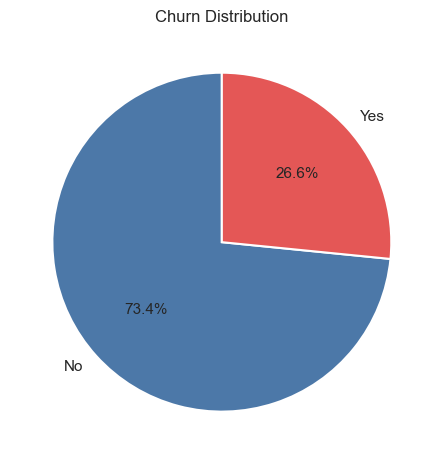

In [123]:
churn_counts = df['Churn'].value_counts().reindex(['No', 'Yes'])
plt.pie(
    churn_counts,
    labels=churn_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=[churn_palette['No'], churn_palette['Yes']],
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5},
    textprops={'fontsize': 11},
)
plt.title('Churn Distribution')
plt.tight_layout()
plt.show()

We can see a clear imbalance here for target column, which needs to be handled during modeling. 73.4 percent of customers stay with the company while 26.6% are churning.

### Demographical Features Analysis

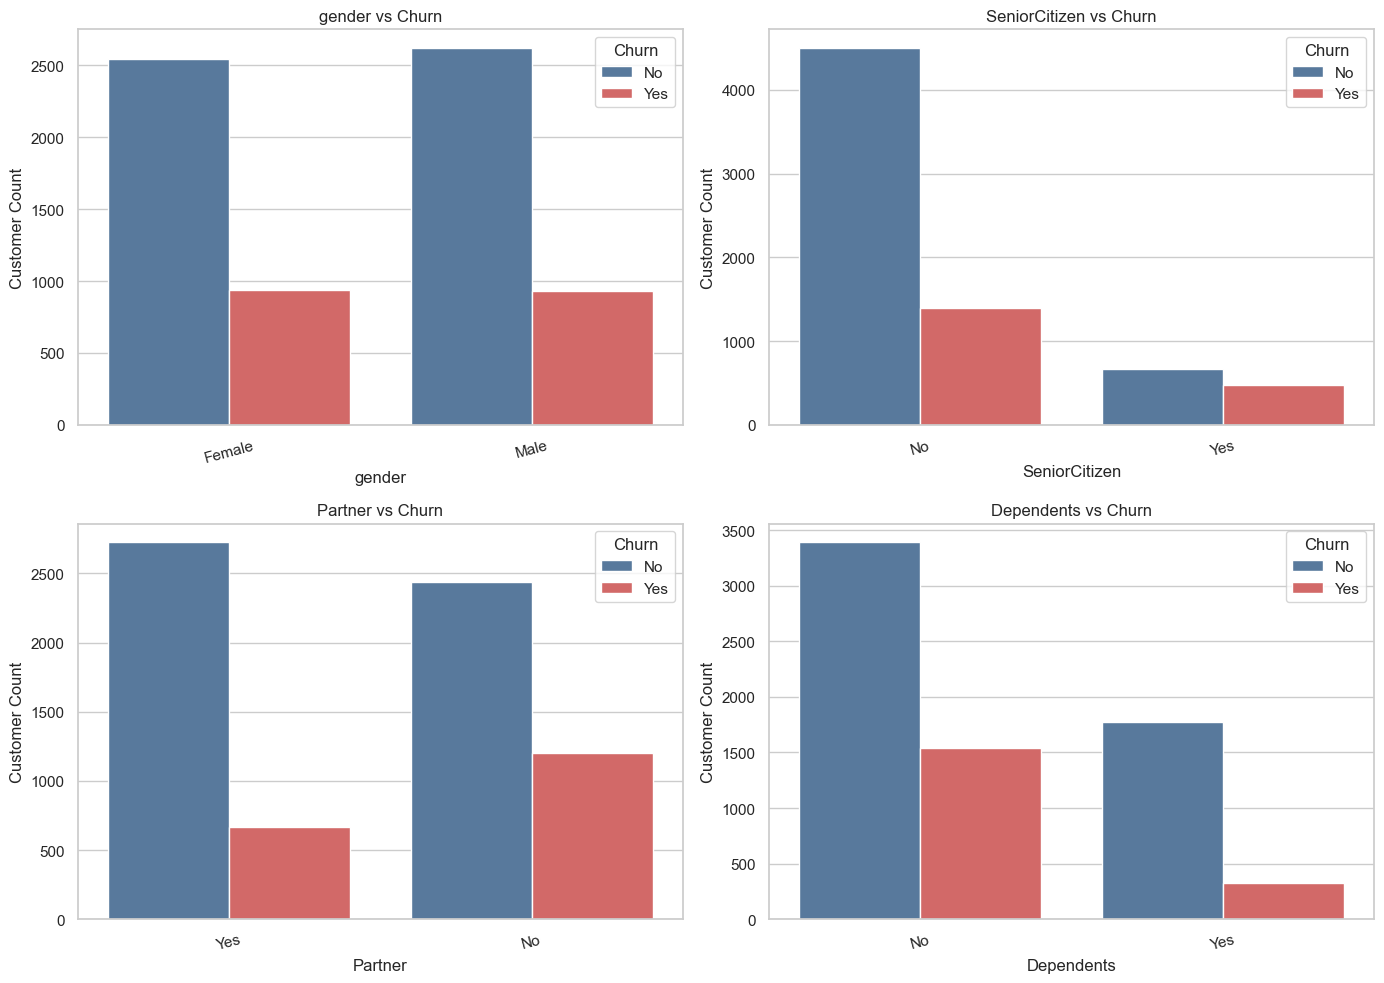

In [124]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
demographic_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents']

for ax, column in zip(axes.flatten(), demographic_cols):
    sns.countplot(data=df, x=column, hue='Churn', palette=churn_palette, ax=ax)
    ax.set_title(f'{column} vs Churn')
    ax.set_xlabel(column)
    ax.set_ylabel('Customer Count')
    ax.tick_params(axis='x', rotation=15)

fig.tight_layout()
plt.show()

Gender shows almost no visible difference in churn behavior. However, senior citizens, customers without partners, and customers without dependents appear to churn at higher rates. This suggests that household-related features may be more useful than gender for predicting churn.


### Contracts and Payments Analysis


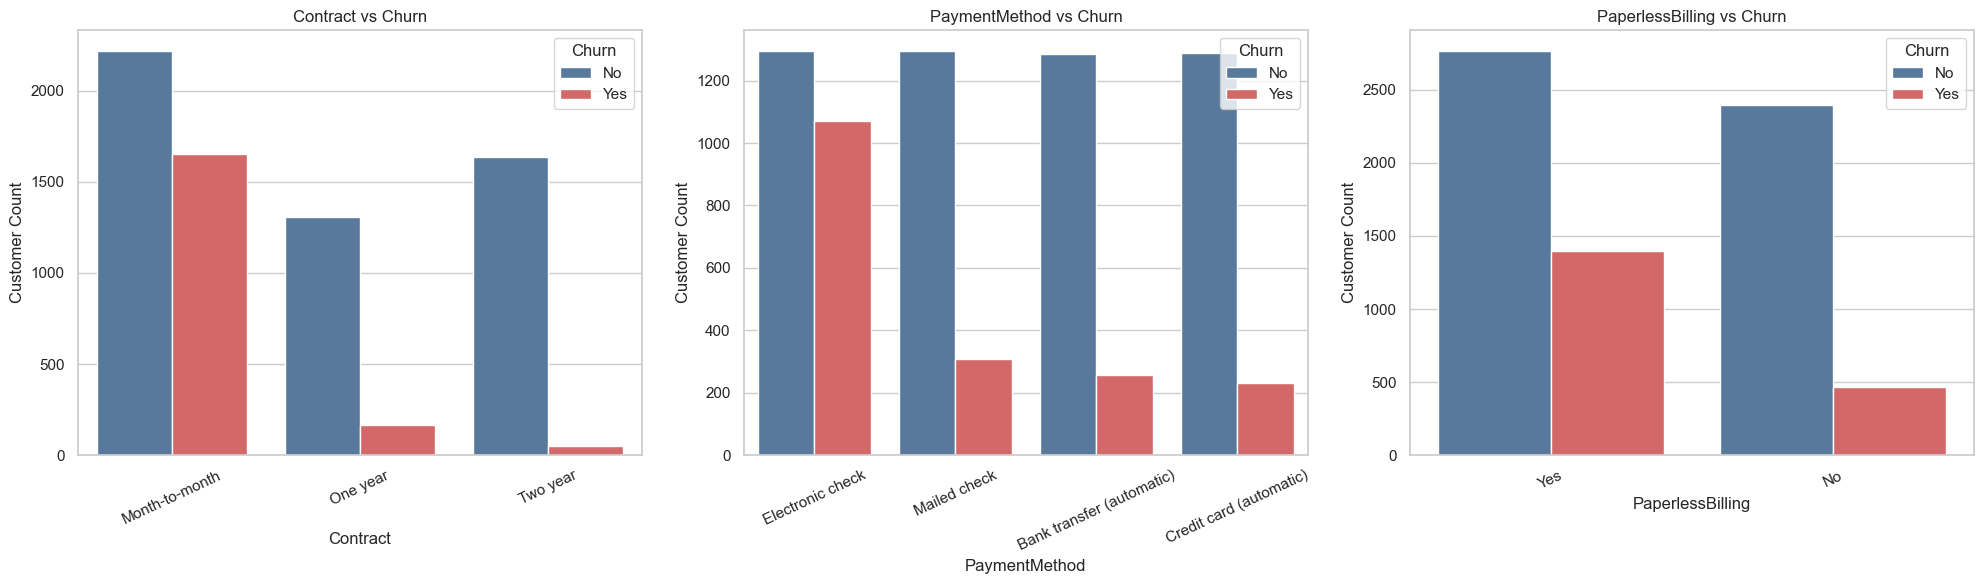

In [125]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
contract_payment_cols = ['Contract', 'PaymentMethod', 'PaperlessBilling']

for ax, column in zip(axes.flatten(), contract_payment_cols):
    sns.countplot(data=df, x=column, hue='Churn', palette=churn_palette, ax=ax)
    ax.set_title(f'{column} vs Churn')
    ax.set_xlabel(column)
    ax.set_ylabel('Customer Count')
    ax.tick_params(axis='x', rotation=25)

fig.tight_layout()
plt.show()


Contract type is one of the clearest churn drivers in the dataset. Month-to-month customers show a much higher churn count than customers on one-year or two-year contracts, suggesting that commitment length strongly reduces churn risk. This is likely because long-term contracts indicate stronger customer loyalty.

Payment method also shows a meaningful pattern: customers using electronic checks churn far more often than customers using mailed checks, bank transfers, or credit cards. This may indicate that electronic check users are less locked into automatic payment behavior or may represent a more price-sensitive customer segment.

Paperless billing customers also show higher churn than non-paperless billing customers. However, this pattern should be interpreted carefully because it may overlap with other high-risk behaviors, such as month-to-month contracts and electronic check payments. Overall, contract type appears to be the strongest signal among these three features, while payment method and paperless billing add useful supporting churn information.


### Internet and Add on Services analysis

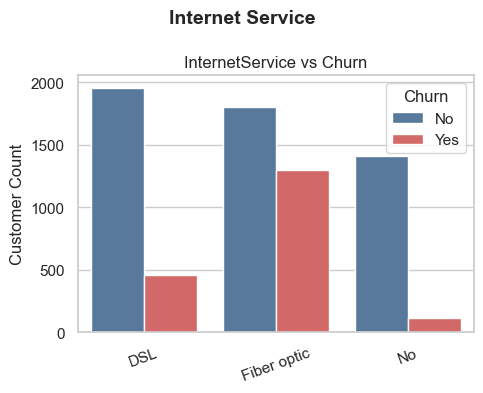

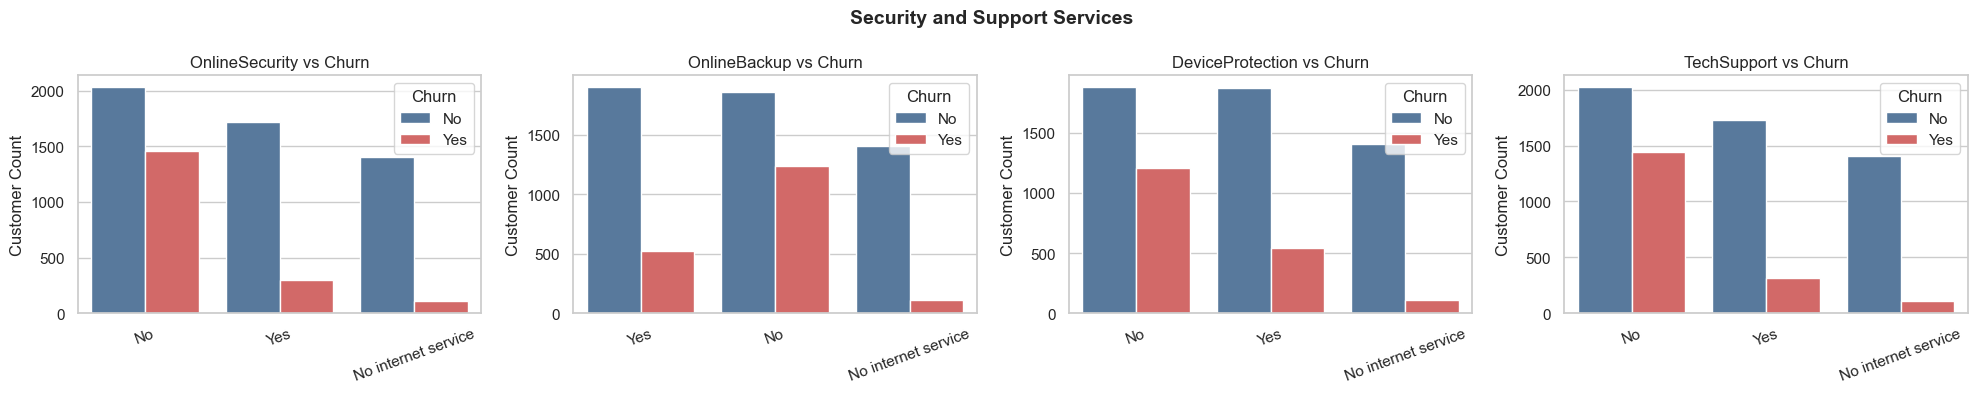

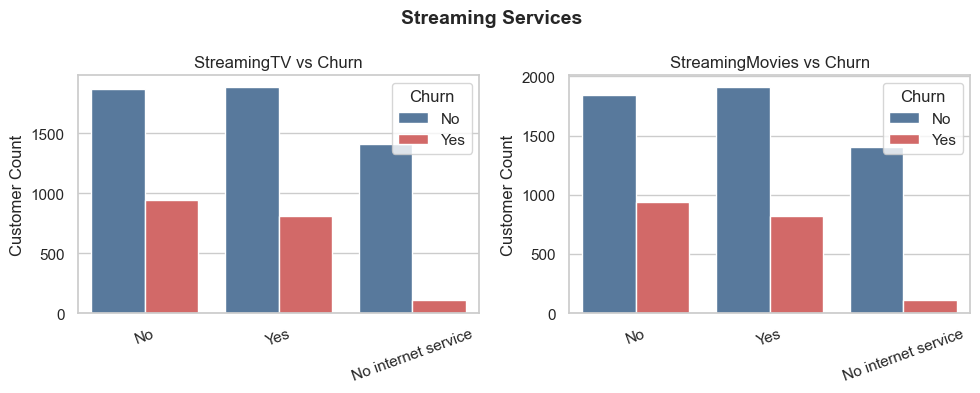

In [126]:
service_groups = {
    "Internet Service": ["InternetService"],
    "Security and Support Services": [
        "OnlineSecurity",
        "OnlineBackup",
        "DeviceProtection",
        "TechSupport"
    ],
    "Streaming Services": [
        "StreamingTV",
        "StreamingMovies"
    ]
}

for group_name, columns in service_groups.items():
    fig, axes = plt.subplots(1, len(columns), figsize=(5 * len(columns), 4))

    if len(columns) == 1:
        axes = [axes]

    for ax, column in zip(axes, columns):
        sns.countplot(
            data=df,
            x=column,
            hue="Churn",
            palette=churn_palette,
            ax=ax
        )
        ax.set_title(f"{column} vs Churn")
        ax.set_xlabel("")
        ax.set_ylabel("Customer Count")
        ax.tick_params(axis="x", rotation=20)

    fig.suptitle(group_name, fontsize=14, fontweight="bold")
    fig.tight_layout()
    plt.show()




#### *   **Internet Service**

Fiber optic customers stand out as the highest-risk service segment: their churn count is close to their retained count, unlike DSL or no-internet customers. This suggests that churn is less about having internet service in general and more about the fiber optic customer experience, pricing, or expectations.


#### *   **Security and Support Services**

Customers without security and support services show noticeably higher churn, especially those without OnlineSecurity or TechSupport. In contrast, customers who have these services churn much less. This suggests that support-related add-ons may increase customer stickiness, while the absence of protection or assistance is a clear churn risk signal.

#### *    **Streaming Services**

Streaming services do not show a strong churn separation. Customers with and without StreamingTV or StreamingMovies have fairly similar churn patterns, so these features appear less predictive than security, support, contract type, or internet service.










## Numerical Features vs Churn

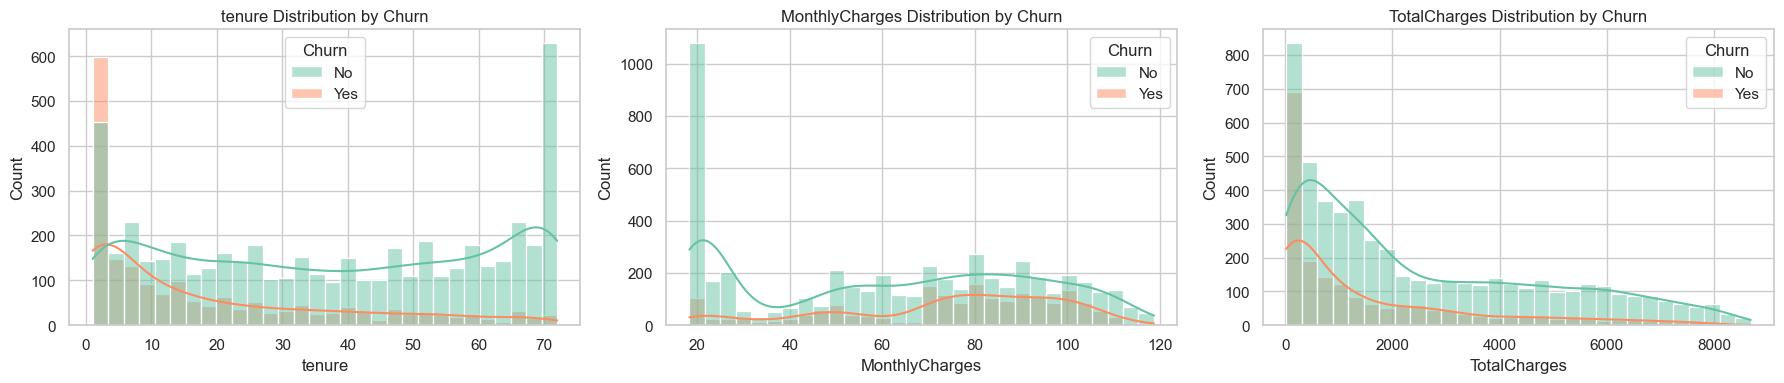

In [127]:
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for ax, col in zip(axes, num_cols):
    sns.histplot(data=df, x=col, hue="Churn", kde=True, bins=30, ax=ax)
    ax.set_title(f"{col} Distribution by Churn")

plt.tight_layout()
plt.show()


Tenure shows one of the strongest churn patterns: churn is heavily concentrated among newer customers, while long-tenure customers are much more likely to stay. MonthlyCharges also shows a useful signal, with churn more visible among customers paying higher monthly fees. TotalCharges is less direct because it is strongly tied to tenure, but lower total charges still align with early customer churn.


## Correlation Heatmap for numerical features

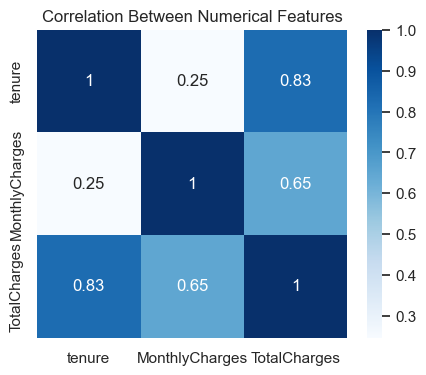

In [128]:
plt.figure(figsize=(5, 4))
sns.heatmap(df[["tenure", "MonthlyCharges", "TotalCharges"]].corr(), annot=True, cmap="Blues")
plt.title("Correlation Between Numerical Features")
plt.show()

TotalCharges is strongly correlated with tenure and moderately correlated with MonthlyCharges, which is expected because total spending grows with both customer lifetime and monthly price. Tenure and MonthlyCharges have only a weak relationship, meaning customers can have high or low monthly bills regardless of how long they have stayed. This suggests that TotalCharges may overlap with tenure, while tenure and MonthlyCharges provide more distinct information.


# **Data Preprocessing**

## Spliting

In [129]:
X = df.drop("Churn", axis=1)
y = df["Churn"].map({"No": 0, "Yes": 1})

print('X shape: ', X.shape)
print('Y shape: ', y.shape)

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=1712,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=1712,
    stratify=y_temp
)

X shape:  (7032, 19)
Y shape:  (7032,)


## One-Hot Encoding

In [130]:
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
cat_cols = X_train.select_dtypes(include="object").columns.tolist()
encoder = OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False)

X_train_cat = encoder.fit_transform(X_train[cat_cols])
X_val_cat = encoder.transform(X_val[cat_cols])
X_test_cat = encoder.transform(X_test[cat_cols])


## Scaling Numerical Features


In [131]:
scaler = StandardScaler()

X_train_num = scaler.fit_transform(X_train[num_cols])
X_val_num = scaler.transform(X_val[num_cols])
X_test_num = scaler.transform(X_test[num_cols])


## Combine

In [132]:
encoded_cols = encoder.get_feature_names_out(cat_cols)

X_train_processed = pd.DataFrame(
    np.hstack([X_train_num, X_train_cat]),
    columns=num_cols + list(encoded_cols),
    index=X_train.index
)

X_val_processed = pd.DataFrame(
    np.hstack([X_val_num, X_val_cat]),
    columns=num_cols + list(encoded_cols),
    index=X_val.index
)

X_test_processed = pd.DataFrame(
    np.hstack([X_test_num, X_test_cat]),
    columns=num_cols + list(encoded_cols),
    index=X_test.index
)


## Handling Imbalanced Target Variable Using SMOTE

In [133]:
smote = SMOTE(random_state=1712)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_processed,
    y_train
)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())


Before SMOTE:
Churn
0    4130
1    1495
Name: count, dtype: int64

After SMOTE:
Churn
0    4130
1    4130
Name: count, dtype: int64


# **Model Training**

## Defining Models

In [134]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=1712),
    "Random Forest": RandomForestClassifier(random_state=1712),
    "XgBoost": XGBClassifier(random_state=1712, eval_metric="logloss"),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB()
}

## Training and evaluating on validation set

In [135]:
train_results = []
val_results = []

for name, model in models.items():
    model.fit(X_train_smote, y_train_smote)

    y_train_pred = model.predict(X_train_processed)
    y_train_prob = model.predict_proba(X_train_processed)[:, 1]

    train_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_train, y_train_pred),
        "Precision": precision_score(y_train, y_train_pred),
        "Recall": recall_score(y_train, y_train_pred),
        "F1 Score": f1_score(y_train, y_train_pred),
        "ROC-AUC": roc_auc_score(y_train, y_train_prob)
    })

    y_val_pred = model.predict(X_val_processed)
    y_val_prob = model.predict_proba(X_val_processed)[:, 1]

    val_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_val, y_val_pred),
        "Precision": precision_score(y_val, y_val_pred),
        "Recall": recall_score(y_val, y_val_pred),
        "F1 Score": f1_score(y_val, y_val_pred),
        "ROC-AUC": roc_auc_score(y_val, y_val_prob)
    })

train_results_df = pd.DataFrame(train_results).sort_values(
    by="F1 Score",
    ascending=False
)

val_results_df = pd.DataFrame(val_results).sort_values(
    by="F1 Score",
    ascending=False
)

print("Training Results")
display(train_results_df)

print("Validation Results")
display(val_results_df)




Training Results


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
1,Random Forest,0.997689,0.993342,0.997993,0.995662,0.999913
2,XgBoost,0.919822,0.850336,0.847492,0.848911,0.973371
3,KNN,0.807111,0.587160,0.923746,0.717962,0.936280
0,Logistic Regression,0.750222,0.519313,0.809365,0.632680,0.845930
4,Naive Bayes,0.667556,0.436762,0.866221,0.580717,0.817334


Validation Results


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.768137,0.542254,0.823529,0.653928,0.852532
1,Random Forest,0.796586,0.629412,0.572193,0.599440,0.828545
2,XgBoost,0.789474,0.608939,0.582888,0.595628,0.841495
4,Naive Bayes,0.671408,0.440541,0.871658,0.585278,0.831629
3,KNN,0.702703,0.462585,0.727273,0.565489,0.780904


The training and validation results show clear differences between the models.

Random Forest performs almost perfectly on the training set, with an F1 score of 0.996 and ROC-AUC of almost 1. However, its validation F1 score drops to 0.599. This large gap suggests that Random Forest is overfitting the training data.

XGBoost also performs very well on the training set, but its validation performance is lower. This means it may also be overfitting, although not as strongly as Random Forest.

Logistic Regression has lower training performance, but it gives the best validation F1 score of 0.654 and the highest validation ROC-AUC of 0.853. This shows that Logistic Regression generalizes better to unseen data.

KNN and Naive Bayes have weaker validation performance compared to Logistic Regression. KNN especially shows a drop from training to validation, which suggests some overfitting.



# **Hyperparameter Tuning**

## Set up CV

In [136]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=1712)

## Defining Models To Be Tuned

In [137]:
tuning_configs = {
    "Logistic Regression Tuned": {
        "model": LogisticRegression(max_iter=3000, random_state=1712),
        "search_type": "grid",
        "params": {
            "clf__C": [0.001, 0.01, 0.1, 0.5, 1, 2, 5, 10, 50],
            "clf__penalty": ["l1", "l2"],
            "clf__solver": ["liblinear"]
        }
    },

    "KNN Tuned": {
        "model": KNeighborsClassifier(),
        "search_type": "grid",
        "params": {
            "clf__n_neighbors": [3, 5, 7, 9, 11, 15, 21, 31, 41],
            "clf__weights": ["uniform", "distance"],
            "clf__metric": ["euclidean", "manhattan", "minkowski"]
        }
    },

    "Naive Bayes Tuned": {
        "model": GaussianNB(),
        "search_type": "grid",
        "params": {
            "clf__var_smoothing": [
                1e-12, 1e-11, 1e-10, 1e-9,
                1e-8, 1e-7, 1e-6, 1e-5, 1e-4
            ]
        }
    },

    "Random Forest Tuned": {
        "model": RandomForestClassifier(random_state=1712),
        "search_type": "random",
        "params": {
            "clf__n_estimators": randint(100, 600),
            "clf__max_depth": [None, 5, 10, 15, 20, 30],
            "clf__min_samples_split": randint(2, 20),
            "clf__min_samples_leaf": randint(1, 10),
            "clf__max_features": ["sqrt", "log2", None],
            "clf__bootstrap": [True, False]
        },
        "n_iter": 40
    },


    "XgBoost Tuned": {
        "model": XGBClassifier(
            random_state=1712,
            eval_metric="logloss",
            n_jobs=-1
        ),
        "search_type": "random",
        "params": {
            "clf__n_estimators": randint(100, 700),
            "clf__max_depth": randint(2, 8),
            "clf__learning_rate": loguniform(0.01, 0.3),
            "clf__subsample": uniform(0.6, 0.4),
            "clf__colsample_bytree": uniform(0.6, 0.4),
            "clf__gamma": uniform(0, 5),
            "clf__reg_alpha": loguniform(1e-4, 10),
            "clf__reg_lambda": loguniform(0.1, 20)
        },
        "n_iter": 60
    }
}


## Tuning Models

In [138]:
best_models = {}
tuning_results = []

for name, config in tuning_configs.items():
    print(f"Tuning {name}...")

    pipe = Pipeline([
        ("smote", SMOTE(random_state = 1712)),
        ("clf", config["model"])
    ])

    if config["search_type"] == "grid":
        search = GridSearchCV(
            estimator=pipe,
            param_grid=config["params"],
            scoring="f1",
            cv=cv,
            n_jobs=-1,
            verbose=1
        )
    else:
        search = RandomizedSearchCV(
            estimator=pipe,
            param_distributions=config["params"],
            n_iter=config["n_iter"],
            scoring="f1",
            cv=cv,
            random_state=1712,
            n_jobs=-1,
            verbose=1
        )

    search.fit(X_train_processed, y_train)

    best_models[name] = search.best_estimator_

    tuning_results.append({
        "Model": name,
        "Search Type": config["search_type"],
        "Best CV F1": search.best_score_,
        "Best Params": search.best_params_
    })

    print(f"Best CV F1: {search.best_score_:.4f}")

tuning_results_df = pd.DataFrame(tuning_results).sort_values(
    by="Best CV F1",
    ascending=False
)

display(tuning_results_df)

Tuning Logistic Regression Tuned...
Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best CV F1: 0.6265
Tuning KNN Tuned...
Fitting 5 folds for each of 54 candidates, totalling 270 fits
Best CV F1: 0.5962
Tuning Naive Bayes Tuned...
Fitting 5 folds for each of 9 candidates, totalling 45 fits
Best CV F1: 0.5796
Tuning Random Forest Tuned...
Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best CV F1: 0.6290
Tuning XgBoost Tuned...
Fitting 5 folds for each of 60 candidates, totalling 300 fits
Best CV F1: 0.6314


,Model,Search Type,Best CV F1,Best Params
4,XgBoost Tuned,random,0.631407,"{'clf__colsample_bytree': 0.646367532758943, '..."
3,Random Forest Tuned,random,0.628998,"{'clf__bootstrap': True, 'clf__max_depth': 5, ..."
0,Logistic Regression Tuned,grid,0.626511,"{'clf__C': 0.1, 'clf__penalty': 'l2', 'clf__so..."
1,KNN Tuned,grid,0.596240,"{'clf__metric': 'manhattan', 'clf__n_neighbors..."
2,Naive Bayes Tuned,grid,0.579584,{'clf__var_smoothing': 1e-12}


XGBoost produced the best cross-validation F1 score after tuning, which is expected for this data because boosting models can capture non-linear relationships and feature interactions. However, its advantage over Logistic Regression and Random Forest is very small, so the final model should not be selected from CV results alone. The tuned models must still be compared on the validation set to check how well they generalize outside the cross-validation folds.


## Tuned Models Evaluation On Validation Set

In [139]:
tuned_train_results = []
tuned_val_results = []

for name, model in best_models.items():
    y_train_pred = model.predict(X_train_processed)

    if hasattr(model.named_steps["clf"], "predict_proba"):
        y_train_prob = model.predict_proba(X_train_processed)[:, 1]
    else:
        y_train_prob = model.decision_function(X_train_processed)

    tuned_train_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_train, y_train_pred),
        "Precision": precision_score(y_train, y_train_pred),
        "Recall": recall_score(y_train, y_train_pred),
        "F1 Score": f1_score(y_train, y_train_pred),
        "ROC-AUC": roc_auc_score(y_train, y_train_prob)
    })

    y_val_pred = model.predict(X_val_processed)

    if hasattr(model.named_steps["clf"], "predict_proba"):
        y_val_prob = model.predict_proba(X_val_processed)[:, 1]
    else:
        y_val_prob = model.decision_function(X_val_processed)

    tuned_val_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_val, y_val_pred),
        "Precision": precision_score(y_val, y_val_pred),
        "Recall": recall_score(y_val, y_val_pred),
        "F1 Score": f1_score(y_val, y_val_pred),
        "ROC-AUC": roc_auc_score(y_val, y_val_prob)
    })

tuned_train_results_df = pd.DataFrame(tuned_train_results).sort_values(
    by="F1 Score",
    ascending=False
)

tuned_val_results_df = pd.DataFrame(tuned_val_results).sort_values(
    by="F1 Score",
    ascending=False
)

print("Tuned Training Results")
display(tuned_train_results_df)

print("Tuned Validation Results")
display(tuned_val_results_df)

Tuned Training Results


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
4,XgBoost Tuned,0.790044,0.578736,0.771906,0.661508,0.867212
1,KNN Tuned,0.756800,0.526186,0.853512,0.651020,0.875611
3,Random Forest Tuned,0.766578,0.541629,0.791973,0.643303,0.854933
0,Logistic Regression Tuned,0.752533,0.522343,0.805351,0.633684,0.845328
2,Naive Bayes Tuned,0.667556,0.436762,0.866221,0.580717,0.817334


Tuned Validation Results


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression Tuned,0.772404,0.548736,0.812834,0.655172,0.853050
4,XgBoost Tuned,0.789474,0.582278,0.737968,0.650943,0.848443
3,Random Forest Tuned,0.751067,0.522727,0.737968,0.611973,0.830095
1,KNN Tuned,0.731152,0.496667,0.796791,0.611910,0.827727
2,Naive Bayes Tuned,0.671408,0.440541,0.871658,0.585278,0.831629


After hyperparameter tuning, the gap between training and validation performance became much smaller for most models. This shows that tuning helped reduce overfitting, especially for Random Forest and XGBoost.
XGBoost achieved the highest training F1 score, but Logistic Regression achieved the best validation F1 score and the highest validation ROC-AUC. This means Logistic Regression generalizes slightly better to unseen data.
Random Forest improved compared to its untuned version, because it no longer has almost perfect training performance. However, its validation F1 score is still lower than Logistic Regression and XGBoost.
KNN and Naive Bayes improved only slightly and still perform weaker than the best models.
Overall, Logistic Regression Tuned is the best model on the validation set because it has the highest F1 score and ROC-AUC, while also keeping training and validation performance balanced. XGBoost Tuned is also a strong candidate, but Logistic Regression is more stable and interpretable.


## Combined Tuned and Untuned

In [140]:
untuned_results_labeled = val_results_df.copy()
untuned_results_labeled["Version"] = "Untuned"

tuned_results_labeled = tuned_val_results_df.copy()
tuned_results_labeled["Version"] = "Tuned"

combined_val_results = pd.concat(
    [untuned_results_labeled, tuned_results_labeled],
    ignore_index=True
)

combined_val_results = combined_val_results[
    ["Model", "Version", "Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]
].sort_values(
    by="F1 Score",
    ascending=False
)

display(combined_val_results)

,Model,Version,Accuracy,Precision,Recall,F1 Score,ROC-AUC
5,Logistic Regression Tuned,Tuned,0.772404,0.548736,0.812834,0.655172,0.853050
0,Logistic Regression,Untuned,0.768137,0.542254,0.823529,0.653928,0.852532
6,XgBoost Tuned,Tuned,0.789474,0.582278,0.737968,0.650943,0.848443
7,Random Forest Tuned,Tuned,0.751067,0.522727,0.737968,0.611973,0.830095
8,KNN Tuned,Tuned,0.731152,0.496667,0.796791,0.611910,0.827727
1,Random Forest,Untuned,0.796586,0.629412,0.572193,0.599440,0.828545
2,XgBoost,Untuned,0.789474,0.608939,0.582888,0.595628,0.841495
3,Naive Bayes,Untuned,0.671408,0.440541,0.871658,0.585278,0.831629
9,Naive Bayes Tuned,Tuned,0.671408,0.440541,0.871658,0.585278,0.831629
4,KNN,Untuned,0.702703,0.462585,0.727273,0.565489,0.780904


This combined validation table compares model performance before and after hyperparameter tuning.
Logistic Regression was already the best untuned model, and tuning improved it slightly. It achieved the highest validation F1 score and ROC-AUC among all models, making it the strongest overall model on the validation set.
XGBoost improved clearly after tuning. Its F1 score increased from 0.596 to 0.651, mainly because recall improved a lot. This shows that tuning helped XGBoost identify more churn customers.
Random Forest also improved after tuning, but its validation performance is still lower than Logistic Regression and XGBoost. This suggests that tuning reduced overfitting, but Random Forest is not the best model for this dataset.
KNN improved after tuning as well, but it remains weaker than the top models. Naive Bayes did not improve after tuning, which is expected because it has very few hyperparameters.
Naive Bayes showed same results after tuning which is again normal because, it has only one hyperparameter to tune and this shows that default parameters were the best ones for this dataset
Overall, hyperparameter tuning improved most models, especially XGBoost, Random Forest, and KNN. However, Tuned Logistic Regression remains the best model based on validation F1 score and ROC-AUC.


# **Test Set Evaluation**

In [141]:
final_candidates = {
    "Untuned Logistic Regression": models["Logistic Regression"],
    "Tuned Logistic Regression": best_models["Logistic Regression Tuned"],
    "Tuned XGBoost": best_models["XgBoost Tuned"]
}

test_results = []

for name, model in final_candidates.items():
    y_test_pred = model.predict(X_test_processed)

    if hasattr(model, "named_steps"):
        clf = model.named_steps["clf"]

        if hasattr(clf, "predict_proba"):
            y_test_prob = model.predict_proba(X_test_processed)[:, 1]
        else:
            y_test_prob = model.decision_function(X_test_processed)
    else:
        if hasattr(model, "predict_proba"):
            y_test_prob = model.predict_proba(X_test_processed)[:, 1]
        else:
            y_test_prob = model.decision_function(X_test_processed)

    test_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_test_pred),
        "Precision": precision_score(y_test, y_test_pred),
        "Recall": recall_score(y_test, y_test_pred),
        "F1 Score": f1_score(y_test, y_test_pred),
        "ROC-AUC": roc_auc_score(y_test, y_test_prob)
    })

test_results_df = pd.DataFrame(test_results).sort_values(
    by="F1 Score",
    ascending=False
)

display(test_results_df)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
2,Tuned XGBoost,0.775568,0.562232,0.700535,0.623810,0.847428
0,Untuned Logistic Regression,0.750000,0.519713,0.775401,0.622318,0.856918
1,Tuned Logistic Regression,0.750000,0.520000,0.764706,0.619048,0.857549


On the test set, the final Tuned XGBoost achieved the best F1 and it would've been chosen as final model if we wanted to choose the model with best F1 score only. But we can see it has the worst recall out of the final candidates. Untuned Logistic regression has the best recall out of those 3, and just a very small difference in ROC-AUC compared to it's tuned version.
The model has moderate - strong recall, meaning it correctly identifies a large portion of customers who actually churn. This is important for a churn prediction problem because missing high-risk customers can be costly for the business.
The precision is lower, which means some customers predicted as churners may not actually churn. However, this trade-off can still be acceptable because retention actions are usually less costly than losing customers.
Overall, the final model, which is Untuned Logistic Regression, generalizes well to unseen data and provides a good balance between churn detection performance and interpretability.


# **Final Evaluation**

In [142]:
final_model = models["Logistic Regression"]

y_test_pred = final_model.predict(X_test_processed)
y_test_prob = final_model.predict_proba(X_test_processed)[:, 1]


## Confusion Matrix

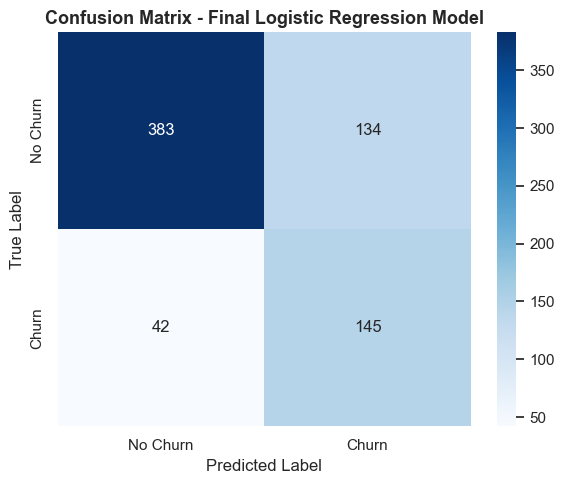

In [143]:
final_model = models["Logistic Regression"]
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.title("Confusion Matrix - Final Logistic Regression Model", fontsize=13, fontweight="bold")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

## ROC-AUC curve

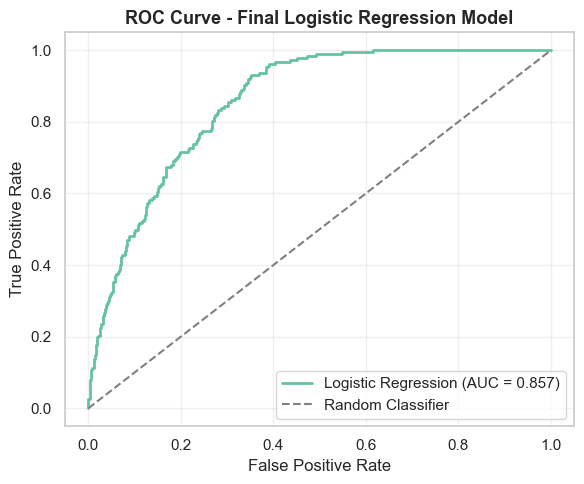

In [144]:
fpr, tpr, thresholds = roc_curve(y_test, y_test_prob)
auc_score = roc_auc_score(y_test, y_test_prob)

plt.figure(figsize=(6, 5))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {auc_score:.3f})",
    linewidth=2
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray",
    label="Random Classifier"
)

plt.title("ROC Curve - Final Logistic Regression Model", fontsize=13, fontweight="bold")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

The final Untuned Logistic Regression model achieves a ROC-AUC of 0.857, indicating strong ability to rank customers by churn risk. This means the model can effectively separate higher-risk customers from lower-risk customers, which is valuable for prioritizing retention efforts.

From the confusion matrix, the model correctly identifies 145 churners while missing only 42, showing that it captures most customers who are likely to leave. This is important from a business perspective because missed churners represent lost retention opportunities. At the same time, the model incorrectly flags 134 non-churn customers as churn risks. These false positives may lead to unnecessary retention offers, but this cost is usually more acceptable than losing actual churn customers.

Overall, the model is well-suited for churn prevention because it prioritizes recall and risk ranking. It can help the business focus retention campaigns on customers most likely to churn, while accepting some false positives as the cost of catching more true churners.


# **Feature Importance**

## Coefficients

In [145]:
log_reg_model = final_model

coefficients = pd.DataFrame({
    "Feature": X_train_processed.columns,
    "Coefficient": log_reg_model.coef_[0],
},
)

top_positive = coefficients.sort_values(
    by="Coefficient",
    ascending=False
).head(10)

top_negative = coefficients.sort_values(
    by="Coefficient",
    ascending=True
).head(10)

print("Top Features Increasing Churn Probability")
display(top_positive)

print("Top Features Decreasing Churn Probability")
display(top_negative)


Top Features Increasing Churn Probability


,Feature,Coefficient
2,TotalCharges,0.957807
10,InternetService_Fiber optic,0.612423
8,MultipleLines_No phone service,0.356071
28,PaymentMethod_Electronic check,0.332168
26,PaperlessBilling_Yes,0.325850
1,MonthlyCharges,0.176901
9,MultipleLines_Yes,0.133292
4,SeniorCitizen_Yes,0.115324
21,StreamingTV_Yes,0.079467
23,StreamingMovies_Yes,0.040176


Top Features Decreasing Churn Probability


,Feature,Coefficient
0,tenure,-1.549729
25,Contract_Two year,-1.431095
24,Contract_One year,-0.722854
19,TechSupport_Yes,-0.592977
13,OnlineSecurity_Yes,-0.448061
7,PhoneService_Yes,-0.381885
15,OnlineBackup_Yes,-0.267613
6,Dependents_Yes,-0.252379
22,StreamingMovies_No internet service,-0.079806
20,StreamingTV_No internet service,-0.079806


## Coefficient Plot

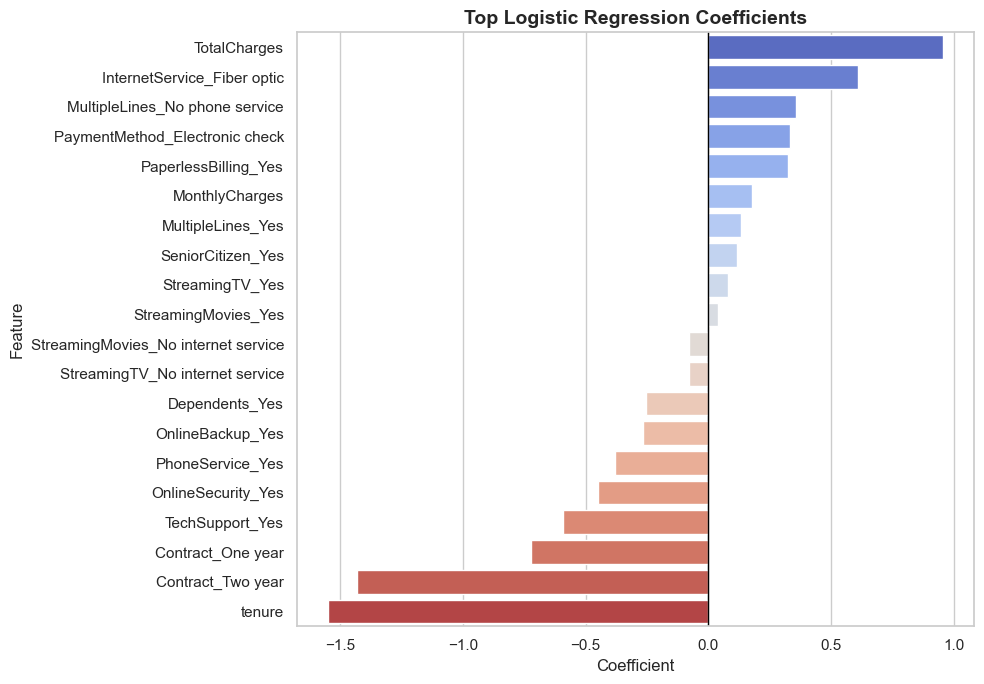

In [146]:
top_features = pd.concat([top_positive, top_negative])

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_features.sort_values("Coefficient", ascending=False),
    x="Coefficient",
    y="Feature",
    palette="coolwarm"
)

plt.axvline(0, color="black", linewidth=1)
plt.title("Top Logistic Regression Coefficients", fontsize=14, fontweight="bold")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


# **FINAL CONCLUSION**

The final Untuned Logistic Regression model performed well on unseen test data, achieving a ROC-AUC score of 0.857 and a recall of 0.775. This means the model is good at ranking customers by churn risk and correctly identifying many customers who are likely to churn.
The model shows that customers with higher total charges, fiber optic internet service, electronic check payment method, paperless billing, and higher monthly charges are more likely to churn. These factors may indicate customers who are paying more or using services linked with higher dissatisfaction.

On the other hand, longer tenure, one-year and two-year contracts, tech support, online security, and having dependents reduce churn probability. This suggests that long-term customers and customers with stronger service support are more likely to stay with the company.

Overall, Untuned Logistic Regression was selected as the final model because it gave one of the best validation performance, generalized well on the test set, and remained easy to interpret. For business use, this model can help identify high-risk customers early, so the company can target them with retention strategies such as better support, contract offers, or personalized discounts.